# 01. Baseline CNN for Melanoma Classification

**Objective**  
Establish a simple unweighted CNN baseline for binary melanoma vs non-melanoma classification. This notebook measures how far a plain convolutional model can go before adding class weighting, threshold tuning, batch normalization, stronger regularization, or augmentation-heavy training.

**Model Architecture**

| Stage | Layers |
| --- | --- |
| Input | RGB dermoscopic image |
| Block 1 | `Conv2d -> ReLU -> MaxPool2d` |
| Block 2 | `Conv2d -> ReLU -> MaxPool2d` |
| Block 3 | `Conv2d -> ReLU -> MaxPool2d` |
| Classifier | `Flatten -> Linear(128 x 28 x 28, 256) -> ReLU -> Dropout -> Linear(256, 1)` |

**Hypothesis**  
A plain CNN trained with standard `BCEWithLogitsLoss` should learn useful visual features and achieve reasonable overall accuracy, but it will likely under-detect melanoma because the training data is imbalanced and the loss is not class-weighted.

### 1. Setup and Imports

This section loads the project modules, training utilities, and evaluation tools, then selects the available compute device (`CUDA`, `MPS`, or `CPU`).

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.models.cnn_baseline import SimpleCNN
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

# Use CUDA if available, otherwise fall back to MPS or CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')


Using device: mps


### 2. Data Split and Baseline Configuration

The dataset is loaded using the predefined train, validation, and test CSV splits.  
The baseline experiment uses:

- `SimpleCNN` as the feature extractor and classifier
- `BCEWithLogitsLoss` with no class weighting
- `Adam` with learning rate `1e-3`
- Batch size `32` and image size `224 x 224`

In [2]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=0,
)

model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### 3. Train the Baseline Model

The model is trained for `20` epochs using the shared trainer utilities.  
Training and validation metrics are stored as lists of dictionaries so they can be passed directly into the shared plotting function later.

The trainer now returns:

- `loss`
- `balanced_accuracy`
- `recall`
- `f2`

The best checkpoint is still selected using validation loss for this baseline notebook.


In [3]:
num_epochs = 20

best_val_auc = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")


    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/cnn_baseline.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')


Epoch [1/20]
  Train | Loss: 0.3312, Bal Acc: 0.4995, Recall: 0.0034, F2: 0.0042, AUC: 0.7216
  Val   | Loss: 0.3155, Bal Acc: 0.5021, Recall: 0.0042, F2: 0.0053, AUC: 0.7911
  -> Saved best model (val AUC: 0.7911)


Epoch [2/20]
  Train | Loss: 0.2953, Bal Acc: 0.5047, Recall: 0.0114, F2: 0.0142, AUC: 0.7817
  Val   | Loss: 0.3064, Bal Acc: 0.5000, Recall: 0.0000, F2: 0.0000, AUC: 0.8105
  -> Saved best model (val AUC: 0.8105)


Epoch [3/20]
  Train | Loss: 0.2875, Bal Acc: 0.4999, Recall: 0.0000, F2: 0.0000, AUC: 0.7982
  Val   | Loss: 0.2804, Bal Acc: 0.5000, Recall: 0.0000, F2: 0.0000, AUC: 0.8330
  -> Saved best model (val AUC: 0.8330)


Epoch [4/20]
  Train | Loss: 0.2748, Bal Acc: 0.5028, Recall: 0.0068, F2: 0.0085, AUC: 0.8238
  Val   | Loss: 0.2999, Bal Acc: 0.5037, Recall: 0.0085, F2: 0.0105, AUC: 0.8247


Epoch [5/20]
  Train | Loss: 0.2709, Bal Acc: 0.5068, Recall: 0.0160, F2: 0.0198, AUC: 0.8311
  Val   | Loss: 0.2825, Bal Acc: 0.4997, Recall: 0.0000, F2: 0.0000, AUC: 0.8283


...

Epoch [16/20]
  Train | Loss: 0.2079, Bal Acc: 0.6685, Recall: 0.3546, F2: 0.3942, AUC: 0.9142
  Val   | Loss: 0.3120, Bal Acc: 0.6087, Recall: 0.2331, F2: 0.2678, AUC: 0.8425


Epoch [17/20]
  Train | Loss: 0.2035, Bal Acc: 0.6714, Recall: 0.3603, F2: 0.4001, AUC: 0.9180
  Val   | Loss: 0.2781, Bal Acc: 0.6299, Recall: 0.2754, F2: 0.3134, AUC: 0.8536


Epoch [18/20]
  Train | Loss: 0.1967, Bal Acc: 0.6919, Recall: 0.4002, F2: 0.4414, AUC: 0.9248
  Val   | Loss: 0.2866, Bal Acc: 0.6496, Recall: 0.3305, F2: 0.3618, AUC: 0.8502


Epoch [19/20]
  Train | Loss: 0.1941, Bal Acc: 0.6987, Recall: 0.4139, F2: 0.4551, AUC: 0.9254
  Val   | Loss: 0.2850, Bal Acc: 0.6337, Recall: 0.2881, F2: 0.3241, AUC: 0.8537


Epoch [20/20]
  Train | Loss: 0.1851, Bal Acc: 0.7077, Recall: 0.4310, F2: 0.4729, AUC: 0.9342
  Val   | Loss: 0.2994, Bal Acc: 0.6643, Recall: 0.3729, F2: 0.3960, AUC: 0.8426


### 4. Plot Training Curves

This notebook now uses the shared evaluation utility to render the standard 2 × 2 training dashboard:

- Loss
- Balanced Accuracy
- Recall
- F2

This replaces the separate manual plotting blocks and keeps the notebook aligned with the new evaluation workflow.


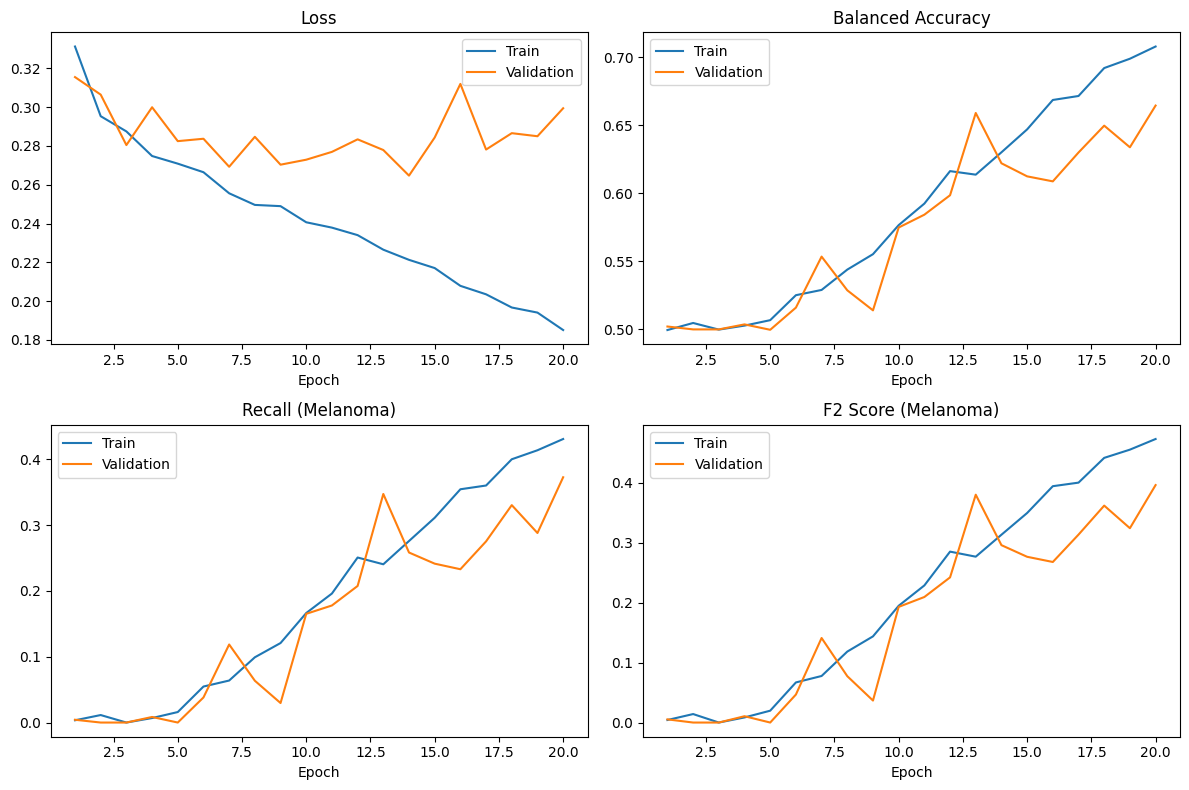

In [4]:
plot_training_curves(train_history, val_history)

### 5. Tune the Classification Threshold on the Validation Set

Instead of fixing the decision threshold at `0.5`, we now search across thresholds from `0.01` to `0.90` and choose the one that maximizes **F2 score** on the validation set.

This is especially important for melanoma detection, where recall is usually more important than raw accuracy.


In [6]:
model.load_state_dict(torch.load(ROOT / 'models/cnn_baseline.pth', map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

print(f"Best validation threshold: {best_threshold:.2f}")
print(f"Best validation F2: {best_f2:.4f}")


Best threshold: 0.07 | Val F2: 0.5997
Best validation threshold: 0.07
Best validation F2: 0.5997


### 6. Evaluate on the Test Set

The best saved baseline checkpoint is reloaded, the optimal validation threshold is found using `find_best_threshold`, and final test performance is reported with the shared evaluation utility.

This standardized evaluation prints and visualizes:

- Threshold used
- AUC-ROC
- Balanced Accuracy
- F2 score
- Classification report
- Confusion matrix
- ROC curve


Threshold:          0.07
AUC-ROC:            0.8449
Balanced Accuracy:  0.7567
F2 Score:           0.5676

              precision    recall  f1-score   support

Non-Melanoma     0.9685    0.6888    0.8051      1340
    Melanoma     0.2527    0.8246    0.3868       171

    accuracy                         0.7042      1511
   macro avg     0.6106    0.7567    0.5959      1511
weighted avg     0.8875    0.7042    0.7577      1511



/Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


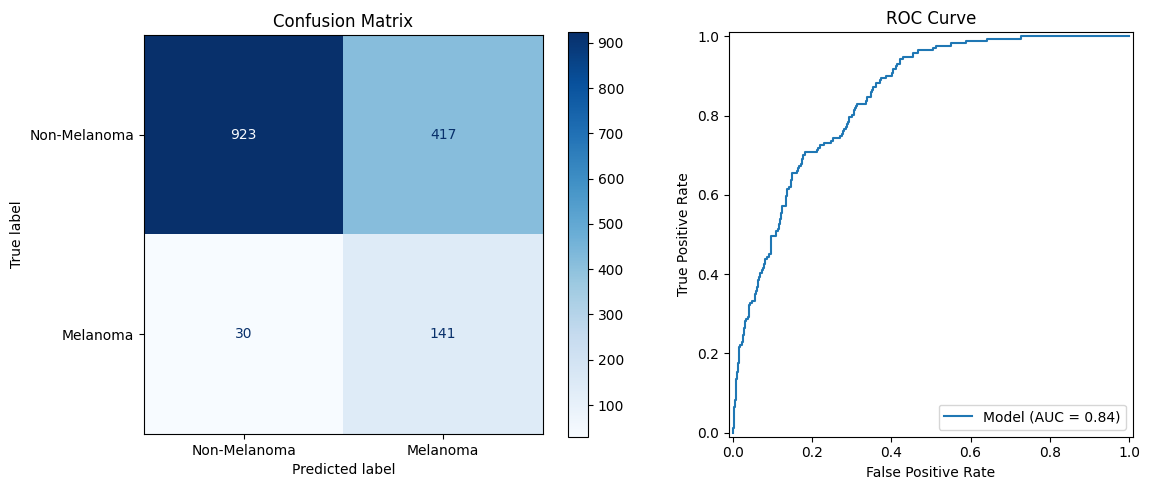

In [7]:
evaluate_model(model, test_loader, device, threshold=best_threshold)

### 7. Baseline Interpretation

### Key Metrics
- **AUC-ROC:** ~0.845  
- **Best Threshold:** 0.07  
- **F2 Score:** ~0.568  
- **Balanced Accuracy:** ~0.757  

### Class-wise Performance
- **Melanoma Recall:** ~0.825  
- **Melanoma Precision:** ~0.25  
- **Non-melanoma Precision:** ~0.97  

### Key Observations
- Model has **good ranking ability** (high AUC)
- Default threshold fails due to **class imbalance**
- Lowering threshold improves **recall significantly**
- Trade-off: higher recall → lower precision

### Conclusion
- Strong baseline model for **learning patterns**
- Requires **threshold tuning to be usable**
- Still not ideal due to **too many false positives**
- Future improvements should focus on:
  - Better precision-recall balance
  - Handling class imbalance
